1. Loading the Dataset

In [21]:
# !pip install medmnist installs the dataset package
!pip install medmnist

# import matplotlib.pyplot as plt imports a tool for showing images
import matplotlib.pyplot as plt

# from medmnist import PneumoniaMNIST imports the dataset
from medmnist import PneumoniaMNIST

2. Downloading the Training Dataset

In [22]:
# train_dataset stores the dataset
# split='train' means we are loading the training set
# download=True means Colab downloads it for us
train_dataset = PneumoniaMNIST(split='train', download=True)

3. Checking the Number of Images

In [23]:
# tells us how many training images are in the dataset.
print("Number of training images:", len(train_dataset))

Number of training images: 4708


4. Import TensorFlow / Keras

In [24]:
# Import TensorFlow, the main deep learning library
import tensorflow as tf

# Import Keras layers and model tools for building a neural network.
from tensorflow.keras import layers, models

5. Build a Simple CNN Model

In [25]:
# Create a CNN model by stacking layers in order.
model = models.Sequential([
    # Define the input shape: 28x28 grayscale image (1 channel)
    layers.Input(shape=(28, 28, 1)),

    # Apply 16 filters of size 3x3 to detect simple image features.
    layers.Conv2D(16, (3, 3), activation='relu'),

    # Reduce the feature map size while keeping important information.
    layers.MaxPooling2D((2, 2)),

    # Apply 32 filters to learn more complex patterns.
    layers.Conv2D(32, (3, 3), activation='relu'),

    # Downsample again to make the model more efficient.
    layers.MaxPooling2D((2, 2)),

    # Convert 2D feature maps into a 1D vector.
    layers.Flatten(),

    # Fully connected layer to combine extracted features.
    layers.Dense(64, activation='relu'),

    # Output one probability for binary classification.
    layers.Dense(1, activation='sigmoid')
])

6. Show Model Structure

In [26]:
# Display the model architecture, output shapes, and number of parameters in each layer.
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,129 (219.25 KB)

 Trainable params: 56,129 (219.25 KB)

 Non-trainable params: 0 (0.00 B)

14. Compile the Model
- loss: how wrong the model is
- optimizer: how the model updates itself
- metrics: what performance we want to monitor

In [27]:
model.compile(
    optimizer='adam',           # Use Adam to update the model weights during training.
    loss='binary_crossentropy', # Use binary cross-entropy because this is a two-class problem.
    metrics=['accuracy']        # Track accuracy to see how often the model predicts correctly.
)

15. Convert dataset to NumPy arrays
- NumPy makes handling large image datasets faster, easier, and compatible with AI models.

In [28]:
import numpy as np

# Convert all training images to NumPy arrays and normalize pixel values to the range [0, 1]
x_train = np.array([np.array(img, dtype=np.float32) / 255.0 for img, label in train_dataset])

# Extract the label for each training image
y_train = np.array([label[0] for img, label in train_dataset])

# Add a channel dimension so the image shape becomes (28, 28, 1)
# This is needed because CNN models expect height, width, and channel
x_train = x_train[..., np.newaxis]

# Print the shapes of the image data and label data
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

x_train shape: (4708, 28, 28, 1)
y_train shape: (4708,)


15. Train the model
- training images = about 4,700, batch size = 32
- then: 4700 % 32 ≈ 148.
- So Colab shows about 148 steps to finish one full epoch.

- You can change the epochs (1 to 10) and batch_size (8, 64, 128)

In [43]:
# Train the CNN model using the training images and labels
history = model.fit(
    x_train, y_train,   # input images and their correct labels
    epochs=30,           # repeat training 5 times over the whole dataset
    batch_size=32       # use 32 images at a time in each training step
)

Epoch 1/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9533 - loss: 0.1216
Epoch 2/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9509 - loss: 0.1221
Epoch 3/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9567 - loss: 0.1129
Epoch 4/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9601 - loss: 0.1079
Epoch 5/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9584 - loss: 0.1032
Epoch 6/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9584 - loss: 0.1119
Epoch 7/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9675 - loss: 0.0904
Epoch 8/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9675 - loss: 0.0913
Epoch 9/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9705 - loss: 0.0824
Epoch 10/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9681 - loss: 0.0836
Epoch 11/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9707 - loss: 0.0805
Epoch 12/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 

16. Visualize loss

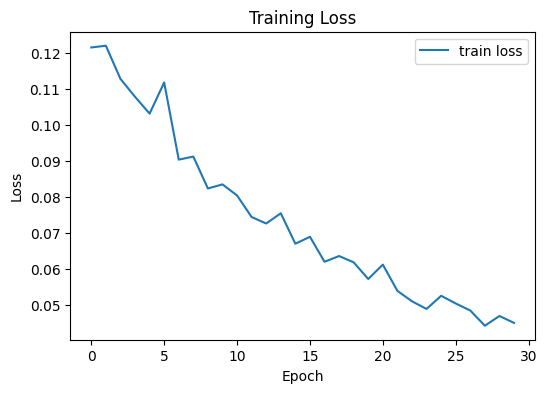

In [44]:
# Create a new figure for the loss graph
plt.figure(figsize=(6,4))

# Plot the training loss recorded after each epoch
plt.plot(history.history['loss'], label='train loss')

# Label the x-axis as Epoch
plt.xlabel('Epoch')

# Label the y-axis as Loss
plt.ylabel('Loss')

# Add a title to the graph
plt.title('Training Loss')

# Show the legend
plt.legend()
plt.show()

17. Visualize accuracy

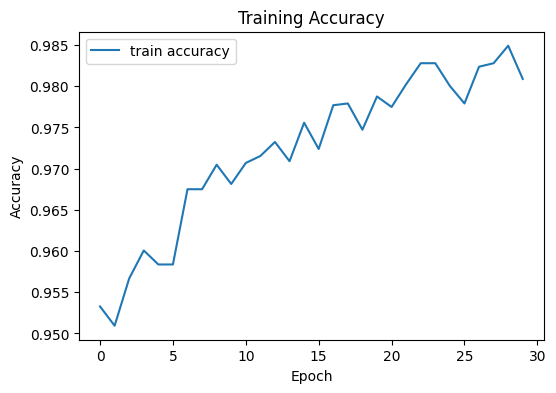

In [45]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='train accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.show()

18. Save the model

- After running this cell, check the Files icon (left) in Colab.
- You should see "my_model.keras" there.
- That means the trained model was saved successfully.

In [46]:
# Save the trained model to a file named "my_model.keras"
model.save('my_model.keras')

# Print a message to confirm that the model has been saved
print("Model saved!")

Model saved!


### Week 4 Colab Notebook ####

19. Load the saved model

In [47]:
from tensorflow.keras.models import load_model

# Load the trained model saved in Week 3
model = load_model("my_model.keras")

# Print a message to confirm that the model was loaded
print("Model loaded!")

Model loaded!


20. Load test dataset

In [48]:
# Load the test split of the PneumoniaMNIST dataset
test_dataset = PneumoniaMNIST(split='test', download=True)

# tells us how many test images are in the dataset.
print("Number of test images:", len(test_dataset))

Number of test images: 624


21. Convert test data to NumPy arrays

In [49]:
# Convert test images to NumPy arrays and normalize pixel values to [0, 1]
x_test = np.array([np.array(img, dtype=np.float32) / 255.0 for img, label in test_dataset])

# Extract the labels for the test images
y_test = np.array([label[0] for img, label in test_dataset])

# Add a channel dimension so the image shape becomes (28, 28, 1)
x_test = x_test[..., np.newaxis]

# Print the shapes of the test images and labels
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_test shape: (624, 28, 28, 1)
y_test shape: (624,)


22. Evaluate the saved model

In [50]:
# Evaluate the model on the test dataset
test_loss, test_acc = model.evaluate(x_test, y_test)

# Print the test results
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8830 - loss: 0.5304
Test Loss: 0.5303782224655151
Test Accuracy: 0.8830128312110901


23. Predict one image (the 1st image in the test dataset)
- You can change the index number to choose another image
- e.g., index = 2, index = 20

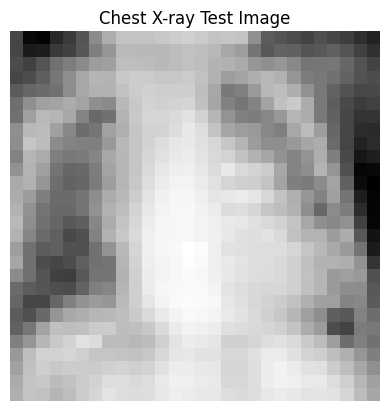

In [38]:
# Select the first test image
index = 0
sample_image = x_test[index]
true_label = y_test[index]

# Display the test image
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title("Chest X-ray Test Image")
plt.axis('off')
plt.show()

24. Predict one image

In [39]:
# Add one more dimension because the model expects a batch
sample_input = np.expand_dims(sample_image, axis=0)

# Predict the probability
prediction = model.predict(sample_input)[0][0]

# Convert probability to class
predicted_label = 1 if prediction >= 0.5 else 0

# Print prediction results
print("Prediction score:", prediction)
print("Predicted label:", predicted_label)
print("True label:", true_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Prediction score: 0.9973349
Predicted label: 1
True label: 1


25. Show the result as text

In [40]:
# Convert numeric labels to class names
label_names = ["Normal", "Pneumonia"]

print("Predicted class:", label_names[predicted_label])
print("True class:", label_names[true_label])

Predicted class: Pneumonia
True class: Pneumonia


26. Try several images

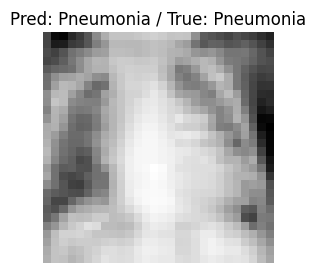

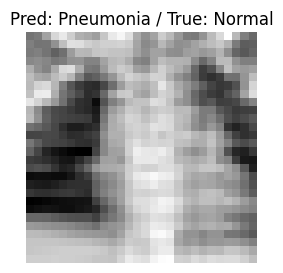

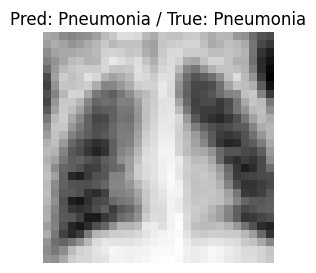

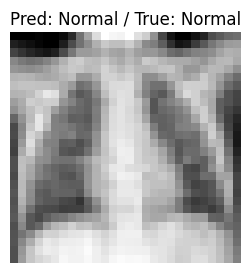

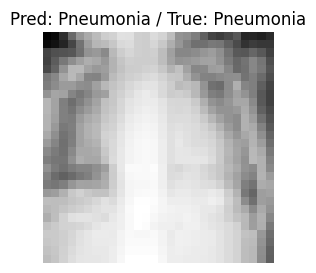

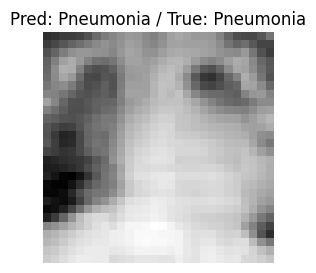

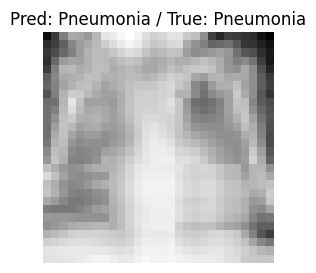

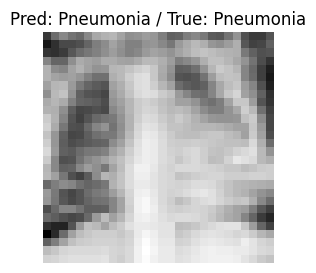

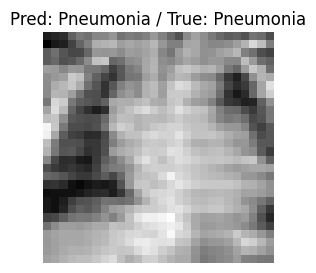

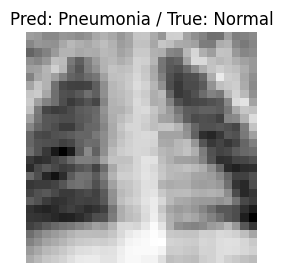

In [42]:
# Show predictions for the first 5 test images
label_names = ["Normal", "Pneumonia"]

for i in range(10):
    image = x_test[i]
    true_label = y_test[i]

    input_image = np.expand_dims(image, axis=0)
    prediction = model.predict(input_image, verbose=0)[0][0]
    predicted_label = 1 if prediction >= 0.5 else 0

    plt.figure(figsize=(3,3))
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f"Pred: {label_names[predicted_label]} / True: {label_names[true_label]}")
    plt.axis('off')
    plt.show()